<h1 style="color: red; text-align: center;">Practical 9: PMF, PDF, and CDF
(Questions)</h1>
<h2 style="color: red;">Instructor: Dr. Khaled Mohamad</h2>


**Import necessary libraries, load the 'students.csv' dataset, display a data sample, determine dataset dimensions, and view the summary statistics for both quantitative and qualitative columns.**

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, binom

In [4]:
df = pd.read_csv("datasets/students.csv")

df.head()

,stud.id,name,gender,age,height,weight,religion,nc.score,semester,major,minor,score1,score2,online.tutorial,graduated,salary
0,833917,"Gonzales, Christina",Female,19,160,64.8,Muslim,1.91,1st,Political Science,Social Sciences,NaN,NaN,0,0,NaN
1,898539,"Lozano, T'Hani",Female,19,172,73.0,Other,1.56,2nd,Social Sciences,Mathematics and Statistics,NaN,NaN,0,0,NaN
2,379678,"Williams, Hanh",Female,22,168,70.6,Protestant,1.24,3rd,Social Sciences,Mathematics and Statistics,45.0,46.0,0,0,NaN
3,807564,"Nem, Denzel",Male,19,183,79.7,Other,1.37,2nd,Environmental Sciences,Mathematics and Statistics,NaN,NaN,0,0,NaN
4,383291,"Powell, Heather",Female,21,175,71.4,Catholic,1.46,1st,Environmental Sciences,Mathematics and Statistics,NaN,NaN,0,0,NaN


In [9]:
df.shape

(8239, 16)

In [5]:
df.describe()

,stud.id,age,height,weight,nc.score,score1,score2,online.tutorial,graduated,salary
count,8239.000000,8239.000000,8239.000000,8239.000000,8239.000000,4892.000000,4892.000000,8239.000000,8239.000000,1753.000000
mean,548910.484525,22.541571,171.380750,72.998131,2.166481,68.164963,69.494685,0.386212,0.212769,42522.112364
std,253849.389811,6.065111,11.077529,8.635162,0.811548,14.051762,14.395251,0.486910,0.409290,10333.139906
min,110250.000000,18.000000,135.000000,51.400000,1.000000,30.000000,31.000000,0.000000,0.000000,11444.141650
25%,331222.500000,20.000000,163.000000,66.500000,1.460000,58.000000,59.000000,0.000000,0.000000,35206.541600
50%,545132.000000,21.000000,171.000000,71.800000,2.040000,70.000000,71.000000,0.000000,0.000000,41672.009750
75%,770807.500000,23.000000,180.000000,78.500000,2.780000,78.000000,80.000000,1.000000,0.000000,49372.540910
max,989901.000000,64.000000,206.000000,116.000000,4.000000,97.000000,98.000000,1.000000,1.000000,75596.793440


In [6]:
df.describe(include="O")

,name,gender,religion,semester,major,minor
count,8239,8239,8239,8239,8239,8239
unique,8174,2,5,7,6,6
top,"Nguyen, Brandon",Male,Catholic,1st,Environmental Sciences,Mathematics and Statistics
freq,3,4129,2797,1709,1626,1446


## Q1: Draw a histogram of 'weight' and provide a short description of your observations with identifying the distribution

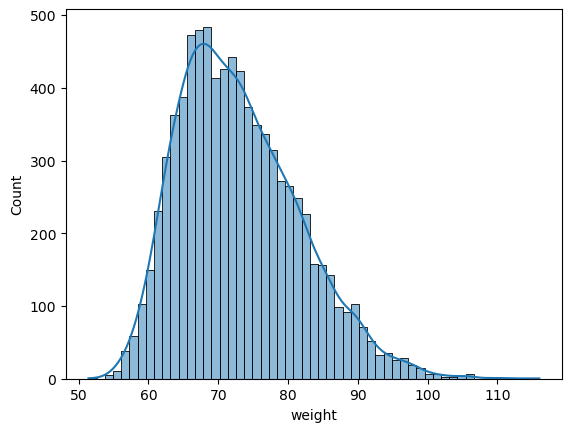

In [15]:
sns.histplot(x="weight", data=df, kde=True)
plt.show()

Slightly right-skewed distribution. The majority of the weighs between 60 and 80 units(probably kgs)

## Q2: Calculate the skewness of 'weight' and explain its significance.

In [17]:
skewness = df['weight'].skew()
print(skewness)

0.651003964853539


We proved that it's moderate positive skew(right). With this assymetry usually:
$$\text{Mode} < \text{Median} < \text{Mean}$$
"Average" weight might be slightly unrepresentative of the most common weight in this group.

## Q3: What is the probability that a student's weight is between 70 kg and 80 kg?
Here, you should use the right distribution function and probability function from
scipy.stats

In [23]:
mean = df['weight'].mean()

std = df['weight'].std()

z1 = (70 - mean) / std
z2 = (80 - mean) / std

p = norm.cdf(z2) - norm.cdf(z1) # norm.cdf(80, mean, std) or without additional satge with Zs

print(p)

0.42705528013215677


## Q4: What is the probability that a student's weight is less than 70 Kg ?
Here, you should use the right distribution function and probability function from
scipy.stats

In [25]:
less_70_p = norm.cdf(70, mean, std)
print(less_70_p)

0.3642204178502991


## Q5: What is the probability that a student's weight is greater than 70 Kg ?
Here, you should use the right distribution function and probability function from
scipy.stats

In [26]:
greater_70_p = 1 - norm.cdf(70, mean, std)
print(greater_70_p)

0.6357795821497009


##  Q6: A company produces electronic components, and their quality control process involves testing each component for defects. The defect rate for these components is 6%. The company recently received a large order for 300 components. They want to determine the probability of having a certain number of defective components in this order.
Here, you should use the right distribution function and probability function from
scipy.stats
## Question 6.1: What is the probability that exactly 10 components out of an order of 300 are defective?

In [27]:
n = 300
p = 0.06

In [28]:
prob_10 = binom.pmf(10, n, p)
print("P(X = 10):", prob_10)

P(X = 10): 0.01362061412812158


## Question 6.2: What is the probability that minimum 10 components out of an order of 300 are defective?

In [32]:
p_least_10 = 1 - binom.cdf(9, n, p) # 9 because starting with 10
print("P(X >= 10):", p_least_10)

P(X >= 10): 0.9868069575023568


## Question 6.3: What is the probability that maximum 10 components out of an order of 300 are defective?

In [33]:
p_most_10 = binom.cdf(10, n, p)
print("P(X <= 10):", p_most_10)

P(X <= 10): 0.026813656625764497


## Question 6.4: Calculate the number of components that are likely to be defective and the standard deviation of the defect probabilities for the 300 components.

In [35]:
mean, var = binom.stats(n, p) # getting mean and variance

std = var**0.5

print("Expected (mean):", mean)
print("Standard deviation:", std)

Expected (mean): 18.0
Standard deviation: 4.113392760240626
